In [2]:
import sys
import os

# Tambahkan src ke path supaya bisa import modul dari sana
sys.path.append(os.path.abspath('../src'))

# Import ulang fungsi load_csv dari file Python kamu
from data.load_data import load_csv

# Load data
df = load_csv('amazon_reviews.csv')
df.head()

Full path: /Users/shifachairunissa/Documents/Database/Data Science Project/Amazon Review Project/data/raw/amazon_reviews.csv


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,313c5638-6584-4650-a62f-365cfb2f2d4f,Darphh,Li love amazon so much it has all the stuff I ...,5,0,28.9.2.100,2024-05-13 23:33:54,28.9.2.100
1,b47ca84a-9609-4815-8d9d-6425a1bef9e9,David B2431,loads quickly.,4,0,28.9.2.100,2024-05-13 23:24:28,28.9.2.100
2,349eeff6-453f-4eb6-a94f-214b0dcefc96,Sinai Luna,My packages have been coming late recently. Wh...,1,0,28.7.0.100,2024-05-13 23:24:19,28.7.0.100
3,017c8f1b-f5a7-4882-8b11-17d336e7444c,Cecilia Armenta,Excellent!!!,5,0,NaN,2024-05-13 23:23:45,NaN
4,e2f2ef27-c936-4d72-82d7-8ec5794ec0a0,Ashley Cyrus,absolutely love Amazon,5,0,28.9.2.100,2024-05-13 23:18:46,28.9.2.100


In [3]:
# ✅ Step 1: Analisis Distribusi Kolom score

df['score'].value_counts()

score
1    24520
5    11301
2     6504
3     4848
4     3384
Name: count, dtype: int64

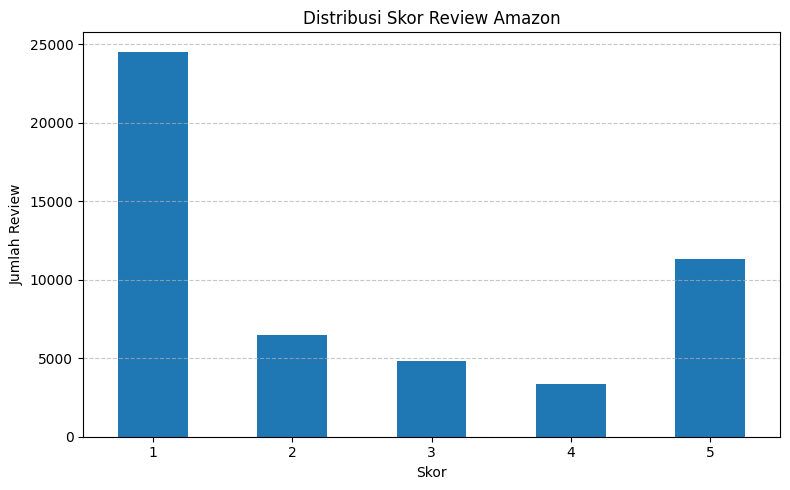

In [6]:
import matplotlib.pyplot as plt

# Hitung distribusi skor
score_counts = df['score'].value_counts().sort_index()

# Buat barplot
plt.figure(figsize=(8, 5))
score_counts.plot(kind='bar')
plt.title('Distribusi Skor Review Amazon')
plt.xlabel('Skor')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# ✅ Step 2: Membersihkan Kolom content

df['content'].sample(5).values

array(["Can't switch languages or countries all of a sudden. I've done that for years in the app to order from, say, Amazon Italy, or Amazon Japan, without an issue. Now the setting is missing from the Settings area. Rather frustrating. Mixing my favorites lists together is also stupid, why do you think we make separate lists in the first place?",
       'great shopping experience, have been let down a few times with non deliveries (amazon prime customer) so should be next day',
       'Great service, terrible app update. New UI is horrendous and a step backwards towards knock-off versions like Alibaba. Much slower browsing speeds and longer loading times.. (not my connection, dont blame the consumer.)',
       "absolutely love Amazon. I've used it for my baby registry and everything I've needed for baby is right at my fingertips. don't have to do anything other then click a button. makes pregnant life so much easier 😁",
       "Have been locked out of my account and can't ever actuall

In [9]:
import string

def clean_text_basic(text):
    # Ubah ke lowercase
    text = text.lower()
    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [11]:
df['clean_content'] = df['content'].apply(clean_text_basic)

df[['content', 'clean_content']].sample(5)

,content,clean_content
45009,App doesn't work anymore. It literally will no...,app doesnt work anymore it literally will not ...
3235,Amazon app says to go to Google play for help....,amazon app says to go to google play for help ...
44443,App is back to crashing every few seconds. Unu...,app is back to crashing every few seconds unus...
10048,"Edit - Still no fix. Sorted by ""Featured"" 40,0...",edit still no fix sorted by featured 40000 re...
1684,Barely getting refunds. It used to be very eas...,barely getting refunds it used to be very easy...


In [14]:
import os
print(os.getcwd())

/Users/shifachairunissa/Documents/Database/Data Science Project/Amazon Review Project/notebooks


In [18]:
# Step 2.2: Load stopwords dari file manual
# Path relatif: naik satu folder dari notebooks → akses stopwords.txt
stopwords_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'stopwords.txt'))

# Baca stopwords
with open(stopwords_path, 'r') as file:
    stop_words = set(file.read().splitlines())

# Fungsi hapus stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Terapkan ke kolom clean_content
df['clean_no_stopwords'] = df['clean_content'].apply(remove_stopwords)

# Lihat hasil
df[['content', 'clean_content', 'clean_no_stopwords']].sample(5)

,content,clean_content,clean_no_stopwords
24855,1. My card's secure payment option is not used...,1 my cards secure payment option is not used b...,1 cards secure payment option amazon feel unco...
4521,I don't purchase products off of Amazon anymor...,i dont purchase products off of amazon anymore...,purchase products amazon quality brands amazon...
23661,So many issues and they just keep getting wors...,so many issues and they just keep getting wors...,issues worse love app reliable easy worst amaz...
44178,Fake and cherry picked reviews. Scam and fake ...,fake and cherry picked reviews scam and fake p...,fake cherry picked reviews scam fake products ...
15844,Amazon Shopping has literally made our lives e...,amazon shopping has literally made our lives e...,amazon shopping literally lives easier pandemi...


In [19]:
# ✂️ Step 2.3 (Opsional) — Stemming atau Lemmatization

from nltk.stem import PorterStemmer

# Inisialisasi stemmer
stemmer = PorterStemmer()

# Fungsi untuk stemming
def stem_text(text):
    words = text.split()
    stemmed = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed)

# Terapkan ke kolom clean_no_stopwords
df['clean_stemmed'] = df['clean_no_stopwords'].apply(stem_text)

# Lihat hasil akhir
df[['clean_no_stopwords', 'clean_stemmed']].sample(5)

,clean_no_stopwords,clean_stemmed
8982,bad stupid application close buyers accounts r...,bad stupid applic close buyer account reason r...
45690,app amazing prices bad,app amaz price bad
11733,idiosyncracies apps written app lockers locker...,idiosyncraci app written app locker locker acc...
24810,amazon alexa popping random notifications bar ...,amazon alexa pop random notif bar start updat
33764,logged bought log stay logged account time uni...,log bought log stay log account time uninstal ...


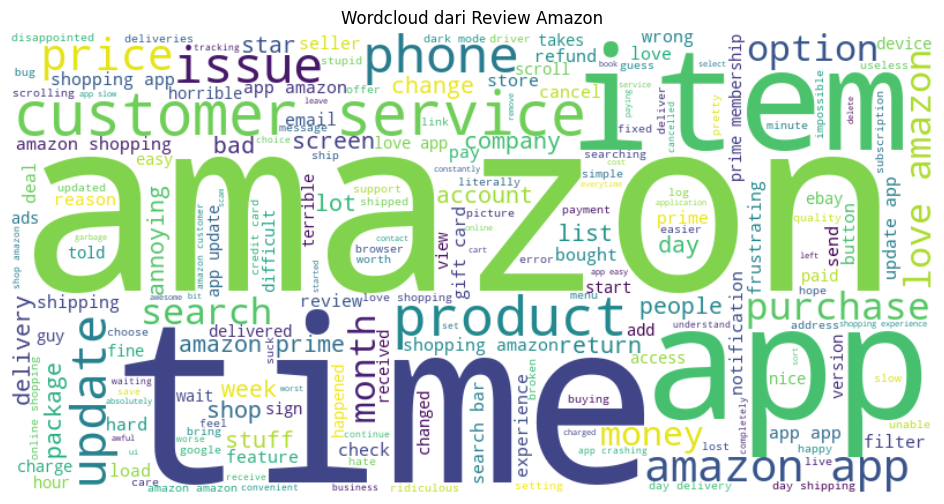

In [20]:
# ✅ Step 3 — Visualisasi Wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua teks menjadi satu string besar
text = ' '.join(df['clean_no_stopwords'].dropna())

# Buat wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud dari Review Amazon')
plt.show()

In [21]:
# ✅ Step 4 — Analisis Top Words per Skor (Positif vs Negatif)

positive_reviews = df[df['score'] >= 4]['clean_no_stopwords']
negative_reviews = df[df['score'] <= 2]['clean_no_stopwords']

In [22]:
positive_text = ' '.join(positive_reviews.dropna())
negative_text = ' '.join(negative_reviews.dropna())

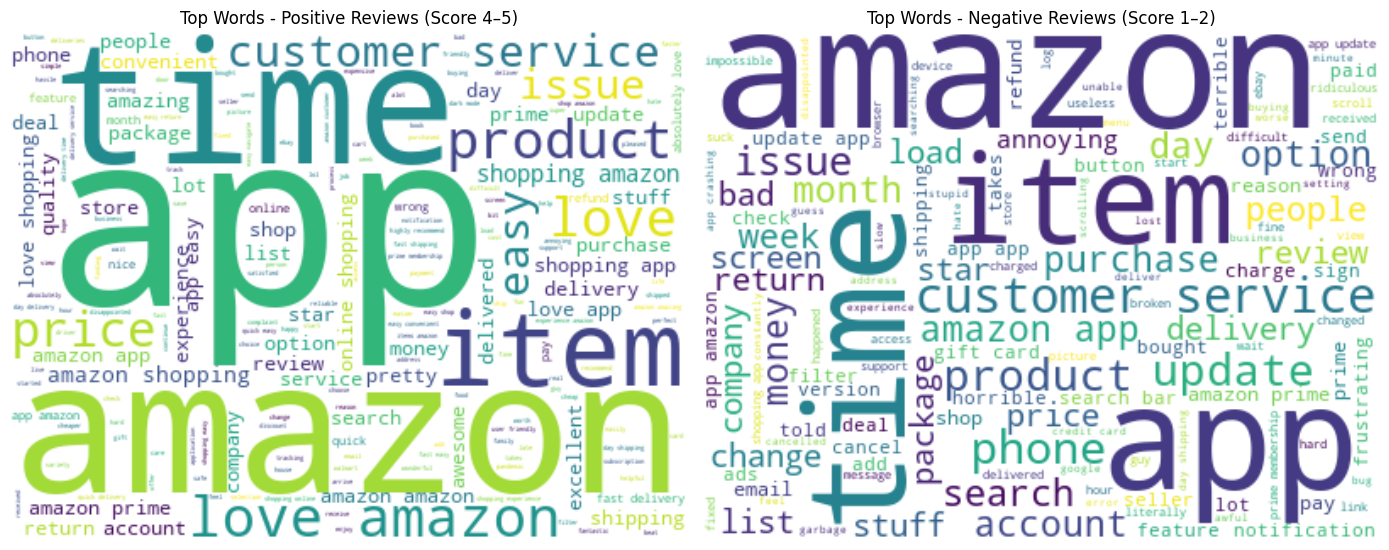

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordCloud positif dan negatif
wordcloud_pos = WordCloud(width=400, height=300, background_color='white').generate(positive_text)
wordcloud_neg = WordCloud(width=400, height=300, background_color='white').generate(negative_text)

# Visualisasi berdampingan
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words - Positive Reviews (Score 4–5)')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words - Negative Reviews (Score 1–2)')

plt.tight_layout()
plt.show()

In [25]:
# ✅ Step 5 — Analisis Tren Waktu dari Review 
import pandas as pd

df['at'] = pd.to_datetime(df['at'])

In [26]:
df.set_index('at', inplace=True)

In [27]:
weekly_reviews = df.resample('W').size()

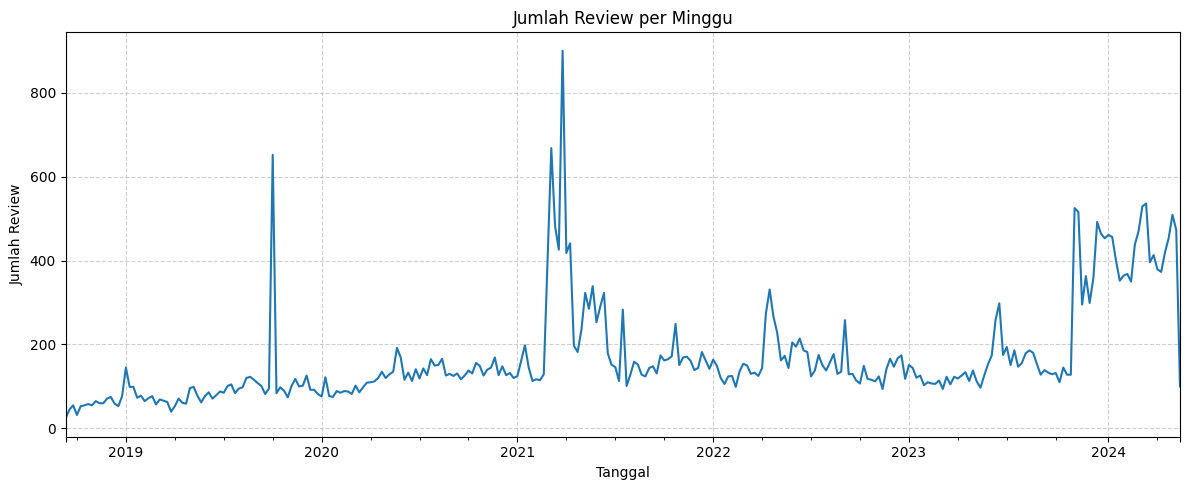

In [28]:
plt.figure(figsize=(12, 5))
weekly_reviews.plot()
plt.title('Jumlah Review per Minggu')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Review')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [29]:
# ✅ Step 5.1 — Tren Rata-Rata Skor per Minggu 

weekly_avg_score = df['score'].resample('W').mean()

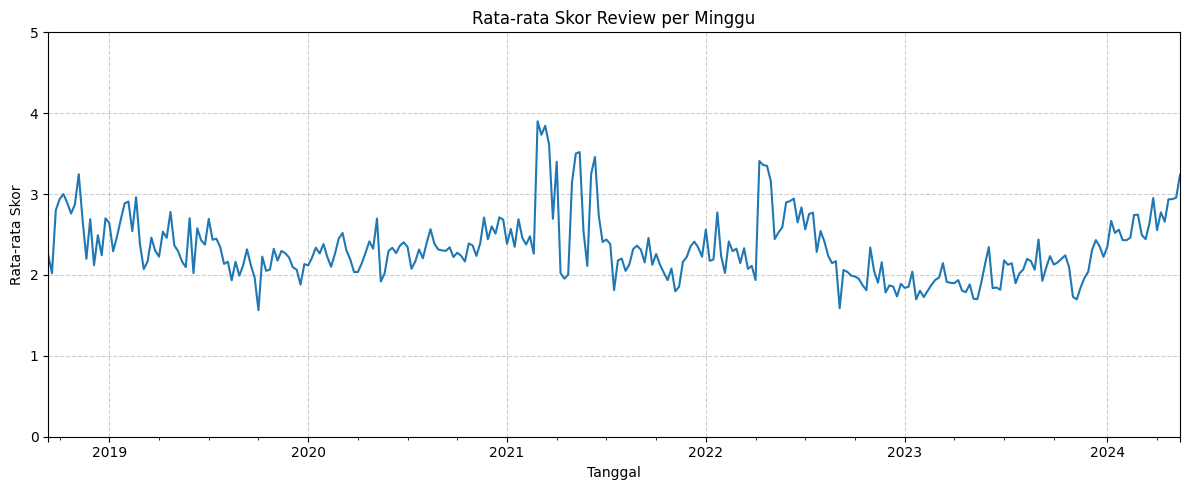

In [30]:
plt.figure(figsize=(12, 5))
weekly_avg_score.plot()
plt.title('Rata-rata Skor Review per Minggu')
plt.xlabel('Tanggal')
plt.ylabel('Rata-rata Skor')
plt.ylim(0, 5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [31]:
# ✅ Step 5.2 — Review Positif vs Negatif per Minggu 

positive = df[df['score'] >= 4]
negative = df[df['score'] <= 2]

In [32]:
weekly_pos = positive['score'].resample('W').count()
weekly_neg = negative['score'].resample('W').count()

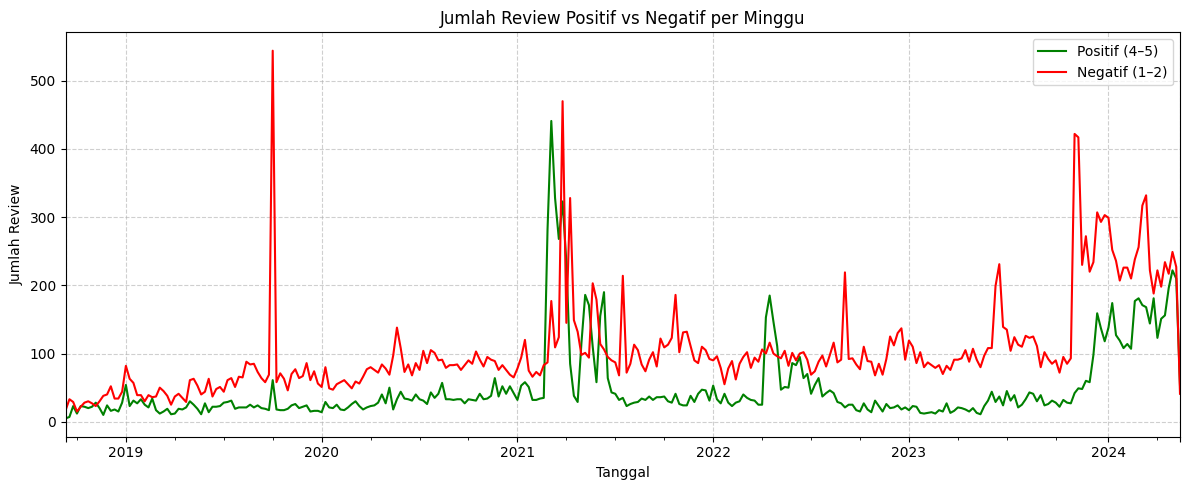

In [33]:
plt.figure(figsize=(12, 5))
weekly_pos.plot(label='Positif (4–5)', color='green')
weekly_neg.plot(label='Negatif (1–2)', color='red')
plt.title('Jumlah Review Positif vs Negatif per Minggu')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Review')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
# ✅ Step 6 — Analisis thumbsUpCount 

df['thumbsUpCount'].describe()

count    50557.000000
mean        13.666792
std         85.699319
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max       5660.000000
Name: thumbsUpCount, dtype: float64

In [35]:
df[['content', 'score', 'thumbsUpCount']].sort_values(by='thumbsUpCount', ascending=False).head(10)

,content,score,thumbsUpCount
at,,,
2020-08-15 18:16:31,Fantastic Shopping App!! Amazon has almost eve...,5,5660
2024-02-19 07:15:14,"Bring back the ""You bought this item at so and...",2,5515
2024-01-25 04:19:31,"Time to fire the product manager! Sadly, still...",1,5213
2019-12-08 18:06:06,"This app works very well, and has never failed...",5,3313
2019-05-02 04:44:33,transitioning from the Souq app has been the w...,1,3197
2020-08-20 18:25:33,"Great Amazon prime asap shipping, but the usua...",3,3109
2019-06-28 10:25:23,The best online shopping app hands down. The i...,5,3044
2023-03-12 00:33:00,It's difficult to find what I'm looking for. T...,1,2994
2020-08-01 02:15:04,This app is great. I love Amazon! If you need ...,2,2671


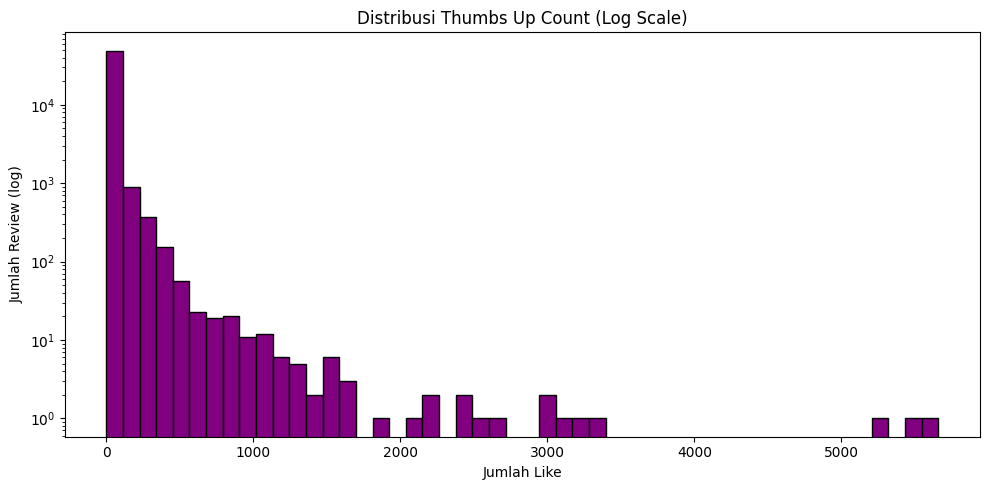

In [36]:
import numpy as np

plt.figure(figsize=(10, 5))
plt.hist(df['thumbsUpCount'], bins=50, log=True, color='purple', edgecolor='black')
plt.title('Distribusi Thumbs Up Count (Log Scale)')
plt.xlabel('Jumlah Like')
plt.ylabel('Jumlah Review (log)')
plt.tight_layout()
plt.show()

✅ Step 7 — Ringkasan Insight & Rekomendasi 

🔹 Distribusi Review:
Mayoritas review berada di skor 5 (positif)

Jumlah skor 1 juga cukup besar → potensi masalah serius

🔹 Review Teks (Wordcloud & Top Words):
Positif: banyak kata seperti love, easy, fast

Negatif: muncul kata seperti slow, late, bad, crash

🔹 Tren Waktu:
Jumlah review konsisten dari minggu ke minggu

Rata-rata skor cukup stabil, namun ada penurunan di beberapa titik waktu

🔹 Review Positif vs Negatif per Minggu:
Review negatif sempat melonjak tajam di periode tertentu (perlu investigasi lebih lanjut)

🔹 Thumbs Up Count:
Review dengan like terbanyak mengandung keluhan detail → user lain menganggapnya penting

Review positif juga ada yang sangat disukai, biasanya yang menyebut fitur spesifik